In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_style("whitegrid")

In [2]:
sentiment_df = pd.read_csv("fear_greed_index.csv")
trades_df = pd.read_csv("historical_data.csv")

In [3]:

print("DATASET SHAPES")


print("Sentiment Shape:", sentiment_df.shape)
print("Trades Shape:", trades_df.shape)

DATASET SHAPES
Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [4]:
sentiment_df.columns = (
    sentiment_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

trades_df.columns = (
    trades_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


print("SENTIMENT COLUMNS")

print(sentiment_df.columns.tolist())


print("TRADES COLUMNS")

print(trades_df.columns.tolist())

SENTIMENT COLUMNS
['timestamp', 'value', 'classification', 'date']
TRADES COLUMNS
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']


In [5]:

print("SENTIMENT SAMPLE")


display(sentiment_df.head())


print("TRADES SAMPLE")

display(trades_df.head())


SENTIMENT SAMPLE


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


TRADES SAMPLE


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:

print("SENTIMENT INFO")


print(sentiment_df.info())


print("TRADES INFO")


print(trades_df.info())

SENTIMENT INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
TRADES INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   account           211224 non-null  object 
 1   coin              211224 non-null  object 
 2   execution_price   211224 non-null  float64
 3   size_tokens       211224 non-null  float64
 4   size_usd          211224 non-null  float64
 5   side              211224 non-null  object 
 6   timestamp_ist     211224 non-null  object 
 7  

In [7]:
time_col = None
for c in ["time", "timestamp", "date", "datetime"]:
    if c in trades_df.columns:
        time_col = c
        break

# PnL column
pnl_col = None
for c in ["closedpnl", "closed_pnl", "pnl"]:
    if c in trades_df.columns:
        pnl_col = c
        break

# Account column
account_col = None
for c in ["account", "wallet", "user"]:
    if c in trades_df.columns:
        account_col = c
        break

# Side column
side_col = None
for c in ["side", "direction"]:
    if c in trades_df.columns:
        side_col = c
        break

# Symbol column
symbol_col = None
for c in ["symbol", "coin", "asset"]:
    if c in trades_df.columns:
        symbol_col = c
        break


print("DETECTED COLUMNS")


print("Timestamp Column:", time_col)
print("PnL Column:", pnl_col)
print("Account Column:", account_col)
print("Side Column:", side_col)
print("Symbol Column:", symbol_col)

DETECTED COLUMNS
Timestamp Column: timestamp
PnL Column: closed_pnl
Account Column: account
Side Column: side
Symbol Column: coin


In [8]:
if time_col is not None:


    print("RAW TIMESTAMP SAMPLE")


    print(trades_df[time_col].head())

    # Numeric timestamp detection
    if np.issubdtype(trades_df[time_col].dtype, np.number):

        max_time = trades_df[time_col].max()

        # Milliseconds
        if max_time > 1e12:
            trades_df[time_col] = pd.to_datetime(
                trades_df[time_col],
                unit="ms"
            )

        # Seconds
        else:
            trades_df[time_col] = pd.to_datetime(
                trades_df[time_col],
                unit="s"
            )

    else:
        trades_df[time_col] = pd.to_datetime(
            trades_df[time_col]
        )


RAW TIMESTAMP SAMPLE
0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: timestamp, dtype: float64


In [9]:
    trades_df["trade_date"] = trades_df[time_col].dt.date
    trades_df["trade_hour"] = trades_df[time_col].dt.hour
    trades_df["day_of_week"] = trades_df[time_col].dt.day_name()

    print("\nTrade Date Range:")
    print(
        trades_df[time_col].min(),
        "->",
        trades_df[time_col].max()
    )


Trade Date Range:
2023-03-28 10:40:00 -> 2025-06-15 15:06:40


In [10]:
if "date" in sentiment_df.columns:
    sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

In [11]:

print("MISSING VALUES")


missing_vals = (
    trades_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing_vals)

MISSING VALUES
account             0
transaction_hash    0
trade_hour          0
trade_date          0
timestamp           0
trade_id            0
fee                 0
crossed             0
order_id            0
closed_pnl          0
coin                0
direction           0
start_position      0
timestamp_ist       0
side                0
size_usd            0
size_tokens         0
execution_price     0
day_of_week         0
dtype: int64


In [12]:

print("DUPLICATE ROWS")

print(trades_df.duplicated().sum())

DUPLICATE ROWS
0


In [13]:

print("NUMERICAL SUMMARY")


numeric_cols = trades_df.select_dtypes(include=np.number).columns

display(
    trades_df[numeric_cols]
    .describe()
    .T
)

NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
execution_price,211224.0,1.141472e+04,2.944765e+04,4.530000e-06,4.854700e+00,1.828000e+01,1.015800e+02,1.090040e+05
size_tokens,211224.0,4.623365e+03,1.042729e+05,8.740000e-07,2.940000e+00,3.200000e+01,1.879025e+02,1.582244e+07
size_usd,211224.0,5.639451e+03,3.657514e+04,0.000000e+00,1.937900e+02,5.970450e+02,2.058960e+03,3.921431e+06
start_position,211224.0,-2.994625e+04,6.738074e+05,-1.433463e+07,-3.762311e+02,8.472793e+01,9.337278e+03,3.050948e+07
closed_pnl,211224.0,4.874900e+01,9.191648e+02,-1.179901e+05,0.000000e+00,0.000000e+00,5.792797e+00,1.353291e+05
order_id,211224.0,6.965388e+10,1.835753e+10,1.732711e+08,5.983853e+10,7.442939e+10,8.335543e+10,9.014923e+10
fee,211224.0,1.163967e+00,6.758854e+00,-1.175712e+00,1.612094e-02,8.957750e-02,3.938110e-01,8.374716e+02
trade_id,211224.0,5.628549e+14,3.257565e+14,0.000000e+00,2.810000e+14,5.620000e+14,8.460000e+14,1.130000e+15
trade_hour,211224.0,1.666529e+01,6.749917e+00,3.000000e+00,1.500000e+01,2.100000e+01,2.100000e+01,2.200000e+01


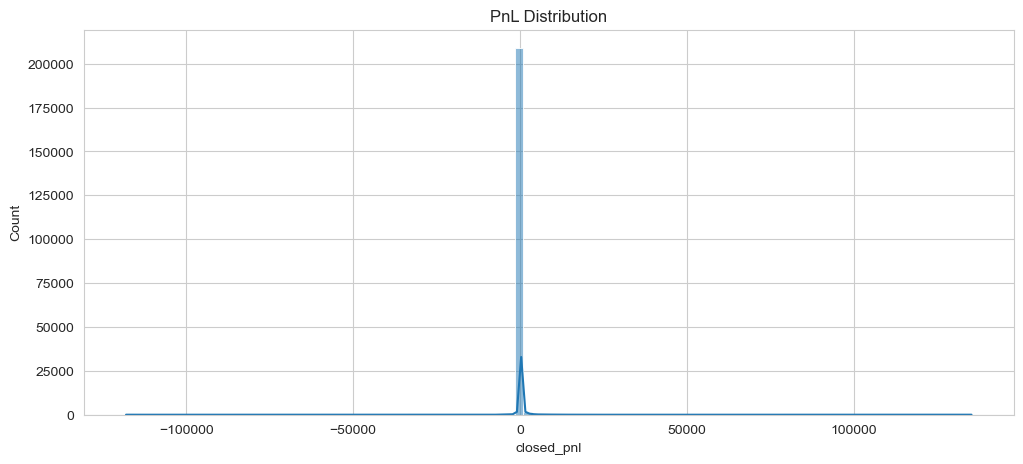

In [14]:
if pnl_col is not None:

    plt.figure(figsize=(12,5))

    sns.histplot(
        trades_df[pnl_col],
        bins=100,
        kde=True
    )

    plt.title("PnL Distribution")

    plt.xlabel(pnl_col)

    plt.show()


SIDE DISTRIBUTION
side
SELL    108528
BUY     102696
Name: count, dtype: int64


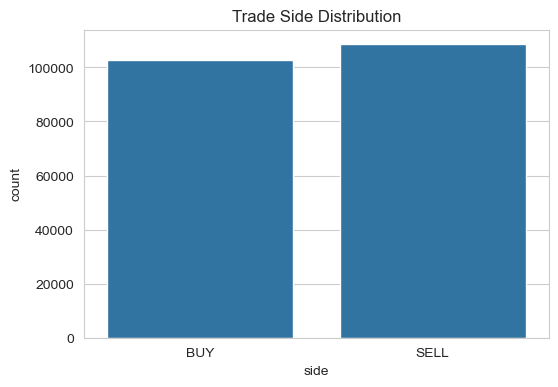

In [15]:
if side_col is not None:


    print("SIDE DISTRIBUTION")


    print(
        trades_df[side_col]
        .value_counts()
    )

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=trades_df,
        x=side_col
    )

    plt.title("Trade Side Distribution")

    plt.show()


In [16]:
if symbol_col is not None:

    print("\n" + "=" * 60)
    print("TOP SYMBOLS")
    print("=" * 60)

    print(
        trades_df[symbol_col]
        .value_counts()
        .head(10)
    )



TOP SYMBOLS
coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


In [17]:
if pnl_col is not None:

    trades_df["is_profitable"] = (
        trades_df[pnl_col] > 0
    ).astype(int)

In [18]:
if account_col is not None and pnl_col is not None:

    trader_metrics = (
        trades_df
        .groupby(account_col)
        .agg(
            total_trades=(account_col, "count"),
            total_pnl=(pnl_col, "sum"),
            avg_pnl=(pnl_col, "mean"),
            median_pnl=(pnl_col, "median"),
            win_rate=("is_profitable", "mean")
        )
        .reset_index()
    )

    trader_metrics["win_rate"] *= 100

    # Add active trading days if available
    if "trade_date" in trades_df.columns:

        active_days = (
            trades_df
            .groupby(account_col)["trade_date"]
            .nunique()
            .reset_index(name="active_days")
        )

        trader_metrics = trader_metrics.merge(
            active_days,
            on=account_col,
            how="left"
        )


    print("TRADER METRICS SAMPLE")


    display(trader_metrics.head())

TRADER METRICS SAMPLE


,account,total_trades,total_pnl,avg_pnl,median_pnl,win_rate,active_days
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,0.000,35.961236,2
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,0.000,44.271978,3
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,0.000,30.191651,4
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,0.000,43.858463,3
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,0.429,51.991355,3


In [19]:
if account_col is not None and pnl_col is not None:

    top_traders = trader_metrics.sort_values(
        "total_pnl",
        ascending=False
    )

    worst_traders = trader_metrics.sort_values(
        "total_pnl",
        ascending=True
    )


    print("TOP 10 TRADERS")


    display(top_traders.head(10))


    print("WORST 10 TRADERS")


    display(worst_traders.head(10))

TOP 10 TRADERS


,account,total_trades,total_pnl,avg_pnl,median_pnl,win_rate,active_days
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2.143383e+06,145.481748,0.000000,33.713432,6
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,0.000000,35.961236,2
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,9.401638e+05,44.364091,0.000000,46.758211,2
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,8.404226e+05,68.684419,0.000000,40.119320,3
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,8.360806e+05,20.806305,0.000000,42.823014,3
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,6.777471e+05,155.589314,0.000000,48.622590,3
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,4.293556e+05,270.034947,0.000000,34.591195,3
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,4.165419e+05,336.735548,0.000000,48.423605,5
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,4.030115e+05,281.826227,0.000000,30.629371,3
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,3.790954e+05,38.319560,7.722845,81.087638,5


WORST 10 TRADERS


,account,total_trades,total_pnl,avg_pnl,median_pnl,win_rate,active_days
19,0x8170715b3b381dffb7062c0298972d4727a0a63b,4601,-167621.124781,-36.431455,0.0,38.274288,3
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-70436.191318,-18.492043,0.0,30.191651,4
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,815,-31203.599986,-38.286626,0.0,45.521472,7
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,3589,14456.919336,4.028119,0.0,32.766787,2
18,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,1559,14900.443047,9.557693,0.0,45.221296,2
26,0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,534,21758.831753,40.746876,0.0,32.209738,2
28,0xb899e522b5715391ae1d4f137653e7906c5e2115,4838,22488.500821,4.648305,0.0,43.861100,1
21,0x8477e447846c758f5a675856001ea72298fd9cb5,14998,43917.008976,2.928191,0.0,26.196826,4
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,47885.320514,6.577654,0.0,44.271978,3
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,332,53496.247243,161.133275,0.0,47.590361,2


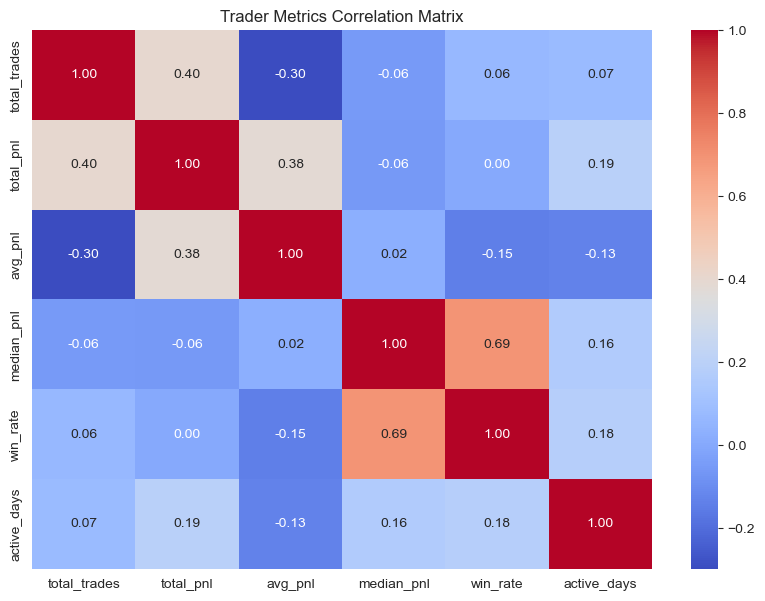

In [20]:
if account_col is not None and pnl_col is not None:

    corr_cols = [
        "total_trades",
        "total_pnl",
        "avg_pnl",
        "median_pnl",
        "win_rate"
    ]

    if "active_days" in trader_metrics.columns:
        corr_cols.append("active_days")

    corr_matrix = trader_metrics[corr_cols].corr()

    plt.figure(figsize=(10,7))

    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Trader Metrics Correlation Matrix")

    plt.show()


In [21]:

print("FINAL DATASET CHECK")


print("Trades Shape:", trades_df.shape)

if account_col is not None:
    print("Unique Traders:", trades_df[account_col].nunique())

if symbol_col is not None:
    print("Unique Symbols:", trades_df[symbol_col].nunique())

if pnl_col is not None:
    print("Total PnL:", trades_df[pnl_col].sum())

FINAL DATASET CHECK
Trades Shape: (211224, 20)
Unique Traders: 32
Unique Symbols: 246
Total PnL: 10296958.943436


In [22]:

# ADVANCED TRADER METRICS


trader_metrics = (
    trades_df
    .groupby("account")
    .agg(
        total_trades=("account", "count"),

        total_pnl=("closed_pnl", "sum"),
        avg_pnl=("closed_pnl", "mean"),
        median_pnl=("closed_pnl", "median"),

        total_volume_usd=("size_usd", "sum"),
        avg_trade_size_usd=("size_usd", "mean"),

        total_fees=("fee", "sum"),
        avg_fee=("fee", "mean"),

        avg_execution_price=("execution_price", "mean"),

        win_rate=("is_profitable", "mean"),

        unique_assets=("coin", "nunique"),

        active_days=("trade_date", "nunique"),

        avg_positions=("start_position", "mean")
    )
    .reset_index()
)

# Convert win rate into %
trader_metrics["win_rate"] *= 100


# ADD RISK/RETURN FEATURES


# Net profitability efficiency
trader_metrics["pnl_per_trade"] = (
    trader_metrics["total_pnl"] /
    trader_metrics["total_trades"]
)

# Fee efficiency
trader_metrics["fee_to_pnl_ratio"] = (
    trader_metrics["total_fees"] /
    (trader_metrics["total_pnl"].abs() + 1)
)

# Volume efficiency
trader_metrics["pnl_to_volume_ratio"] = (
    trader_metrics["total_pnl"] /
    (trader_metrics["total_volume_usd"] + 1)
)

# Trading intensity
trader_metrics["trades_per_day"] = (
    trader_metrics["total_trades"] /
    trader_metrics["active_days"]
)


# DISPLAY RESULTS



print("TRADER METRICS")


display(trader_metrics.head())

print("\nShape:", trader_metrics.shape)

TRADER METRICS


,account,total_trades,total_pnl,avg_pnl,median_pnl,total_volume_usd,avg_trade_size_usd,total_fees,avg_fee,avg_execution_price,win_rate,unique_assets,active_days,avg_positions,pnl_per_trade,fee_to_pnl_ratio,pnl_to_volume_ratio,trades_per_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,0.000,61697263.97,16159.576734,7405.312304,1.939579,2065.999872,35.961236,2,2,-1247.334684,419.127768,0.004628,0.025937,1909.000000
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,0.000,12035487.66,1653.226327,2729.837889,0.374978,265.622352,44.271978,12,3,11181.808655,6.577654,0.057007,0.003979,2426.666667
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,0.000,33873440.42,8893.000898,9280.982850,2.436593,15953.138177,30.191651,8,4,-10248.195171,-18.492043,0.131763,-0.002079,952.250000
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,0.000,6757022.10,507.626933,2218.367366,0.166657,6537.333556,43.858463,94,3,17817.982104,9.951530,0.016747,0.019604,4437.000000
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,0.429,10166880.20,3138.894782,3108.196722,0.959616,18.484069,51.991355,49,3,472411.528070,52.071011,0.018429,0.016589,1079.666667



Shape: (32, 18)


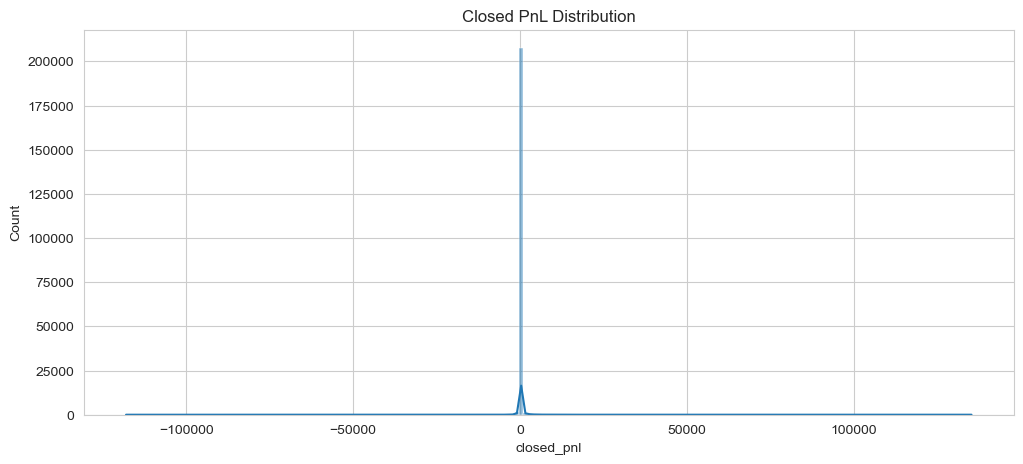

In [23]:
plt.figure(figsize=(12,5))

sns.histplot(
    trades_df["closed_pnl"],
    bins=200,
    kde=True
)

plt.title("Closed PnL Distribution")

plt.show()

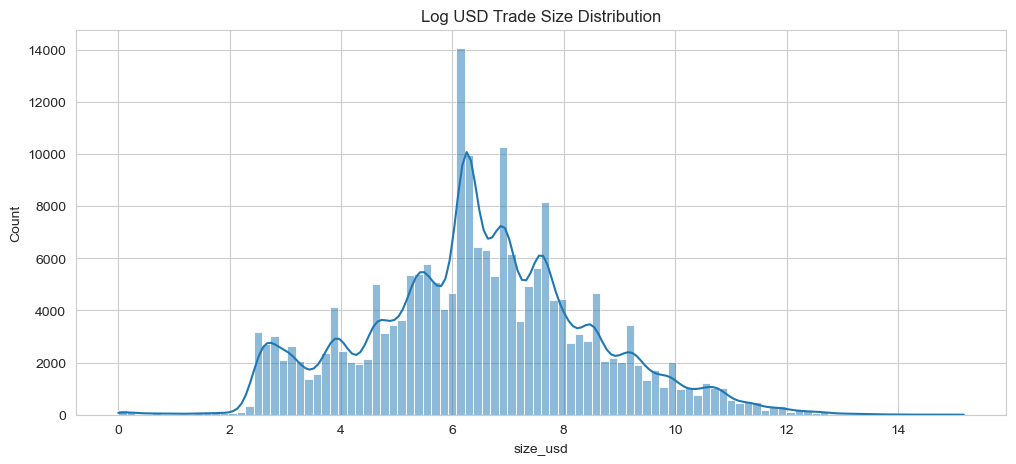

In [24]:
plt.figure(figsize=(12,5))

sns.histplot(
    np.log1p(trades_df["size_usd"]),
    bins=100,
    kde=True
)

plt.title("Log USD Trade Size Distribution")

plt.show()

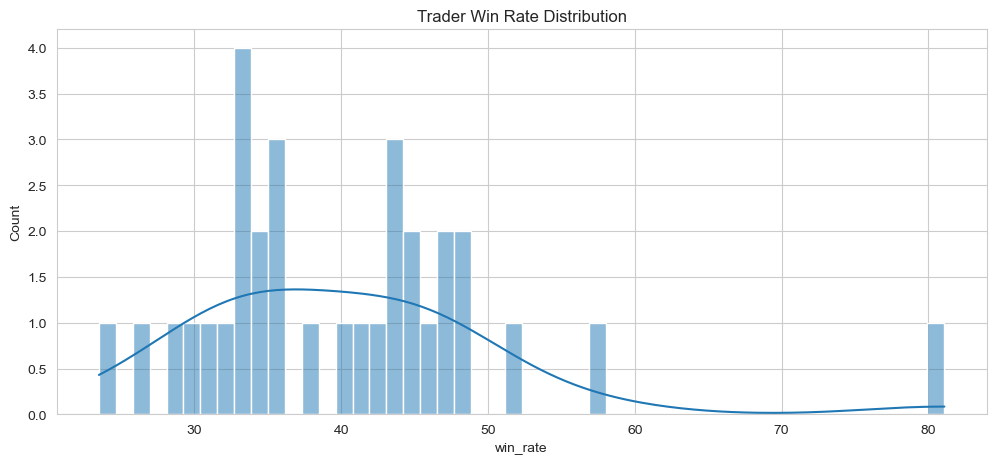

In [25]:
plt.figure(figsize=(12,5))

sns.histplot(
    trader_metrics["win_rate"],
    bins=50,
    kde=True
)

plt.title("Trader Win Rate Distribution")

plt.show()

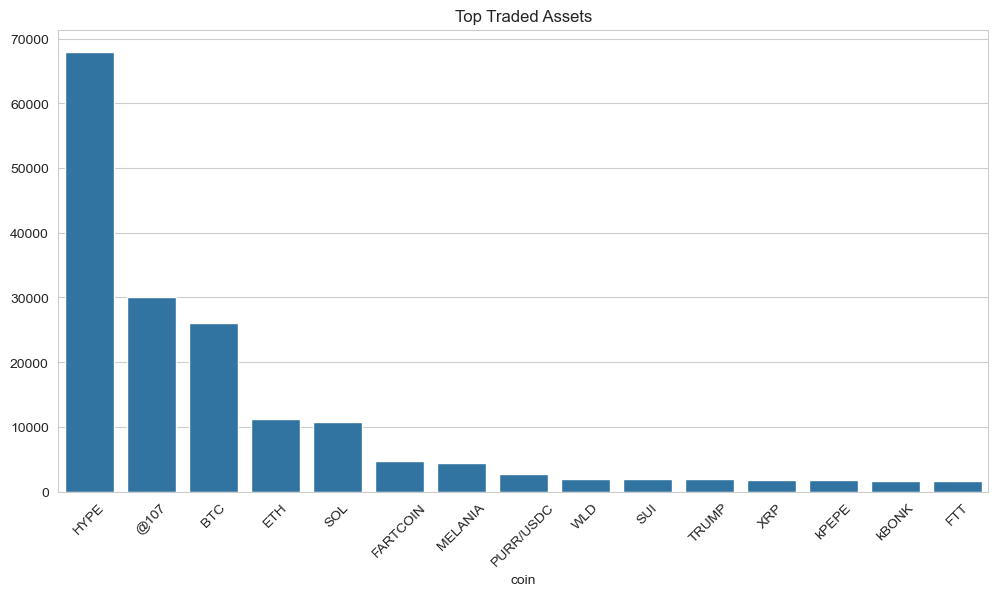

In [26]:
top_assets = (
    trades_df["coin"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_assets.index,
    y=top_assets.values
)

plt.xticks(rotation=45)

plt.title("Top Traded Assets")

plt.show()

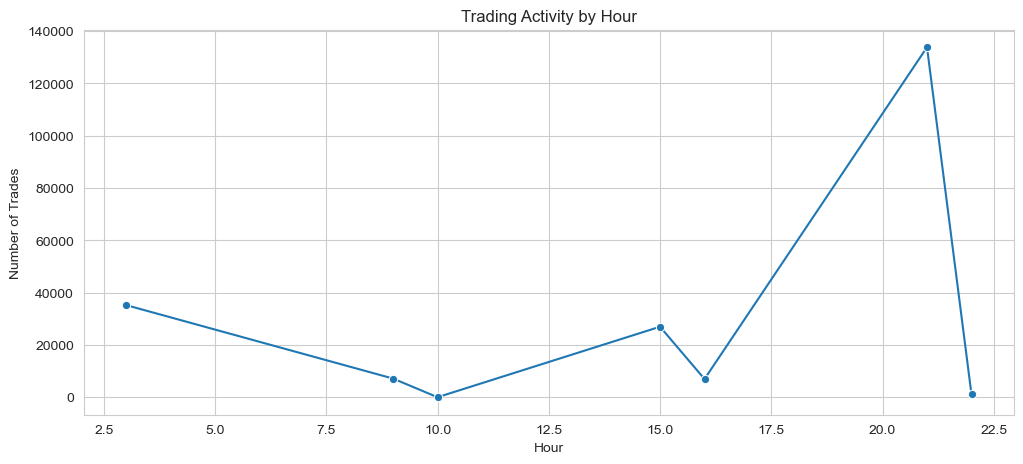

In [27]:
hourly_activity = (
    trades_df
    .groupby("trade_hour")
    .size()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=hourly_activity.index,
    y=hourly_activity.values,
    marker="o"
)

plt.title("Trading Activity by Hour")

plt.xlabel("Hour")
plt.ylabel("Number of Trades")

plt.show()

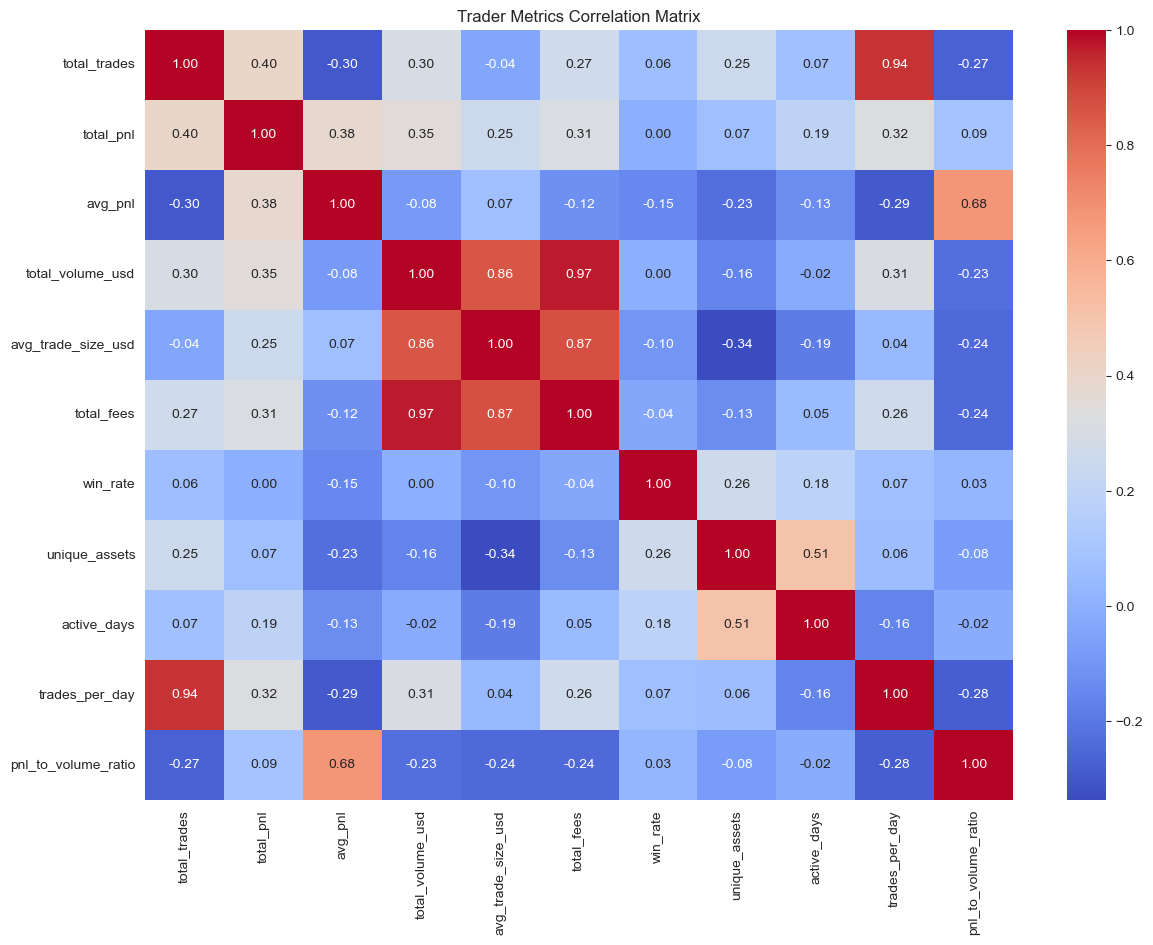

In [28]:
corr_cols = [
    "total_trades",
    "total_pnl",
    "avg_pnl",
    "total_volume_usd",
    "avg_trade_size_usd",
    "total_fees",
    "win_rate",
    "unique_assets",
    "active_days",
    "trades_per_day",
    "pnl_to_volume_ratio"
]

corr_matrix = trader_metrics[corr_cols].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Trader Metrics Correlation Matrix")

plt.show()